In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms

from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# For GPU computation

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu' )
print(device)

cuda


## 📦 About the Dataset: Oxford-IIIT Pet

The **Oxford-IIIT Pet Dataset** contains 37 categories of cat and dog breeds, with roughly 200 images per class. For this U-Net project, we use it for **semantic segmentation**, where the goal is to classify every pixel of an image as pet, background, or boundary.

### 🔑 Each sample = (Image, Mask)

Every item returned by the dataset is a pair:

- **Image** → a PIL Image in standard **RGB** format (3 channels).
- **Mask** → a PIL Image acting as a **2D matrix**, where each pixel holds an **integer label** instead of a color. This integer tells us what that pixel belongs to (pet / background / boundary).

### ⚙️ Why `target_type = 'segmentation'`?

By default, `torchvision.datasets.OxfordIIITPet` uses `target_types='category'`, which means the "target" returned is just a **single integer representing the breed class** (e.g., 0 = Abyssinian, 1 = Bengal, ...) — useful for classification, **not** segmentation.

Since we're building a U-Net (which needs pixel-wise labels, not a single class per image), we must explicitly set:

```python
target_type = 'segmentation'
```

This makes the dataset return the **pixel-wise mask** instead of a class label — exactly what U-Net needs to learn "what pixel belongs to what."

### 🎭 Understanding the Mask

The mask is a 2D array where every pixel has one of **3 integer values**:

| Mask value | Meaning |
|:----------:|---------|
| `1` | 🐱🐶 Foreground / Pet |
| `2` | ⬛ Background |
| `3` | 🟨 Boundary around the pet |

**Example:** if a mask (cropped region) looks like this:

```
2 2 2 2 2 2
2 2 3 3 2 2
2 3 1 1 3 2
2 1 1 1 1 2
2 2 2 2 2 2
```

We can read it as:
- `2` → background (outer region)
- `3` → boundary (thin ring separating pet from background)
- `1` → pet (the actual cat/dog pixels)

### ⚠️ Important: `1` does NOT mean "cat" specifically

This dataset contains **both cats and dogs**, and the mask does **not** distinguish between the two species. The label `1` simply means **"foreground / pet"** — its actual meaning depends on which image it belongs to:

- If the image is of a **cat** → `1` = cat pixels
- If the image is of a **dog** → `1` = dog pixels

So the mask only tells you **"pet vs. not pet"** (plus boundary), not **which animal** it is. If you need species/breed info too, that comes from the separate classification label, not the mask.

In [ ]:
# Loading 'Oxford-IIIT Pet' dataset

def data_transforms(image, mask):
    # Apply ToTensor to the image, scaling it to [0.0, 1.0]
    image = transforms.ToTensor()(image)
    # Convert mask to a LongTensor. Masks are typically integer labels.
    mask = torch.from_numpy(np.array(mask, dtype=np.int64))
    if mask.ndim == 3 and mask.shape[0] == 1:                       # Ensure it's a 2D tensor (H, W) if it came as a 3D (1, H, W) PIL image
        mask = mask.squeeze(0)
    return image, mask

train_data = datasets.OxfordIIITPet(root = './data', download = True, split = 'trainval', target_types = 'segmentation', transforms = data_transforms)
test_data = datasets.OxfordIIITPet(root = './data', download = True, split = 'test', target_types = 'segmentation', transforms = data_transforms)

100%|██████████| 792M/792M [00:35<00:00, 22.1MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 10.8MB/s]


In [ ]:
# Info about the dataset

print(f'Number of training examples: {len(train_data)}')
print(f'Number of testing examples: {len(test_data)}')


img, mask = train_data[0]

print("Image:", type(img), img.shape)
print("Mask :", type(mask), mask.shape)
print("Mask unique values:", torch.unique(mask))

print()
print(mask)

Number of training examples: 3680
Number of testing examples: 3669
Image: <class 'torch.Tensor'> torch.Size([3, 500, 394])
Mask : <class 'torch.Tensor'> torch.Size([500, 394])
Mask unique values: tensor([1, 2, 3])

tensor([[2, 2, 2,  ..., 2, 2, 2],
        [2, 2, 2,  ..., 2, 2, 2],
        [2, 2, 2,  ..., 2, 2, 2],
        ...,
        [2, 2, 2,  ..., 2, 2, 2],
        [2, 2, 2,  ..., 2, 2, 2],
        [2, 2, 2,  ..., 2, 2, 2]])


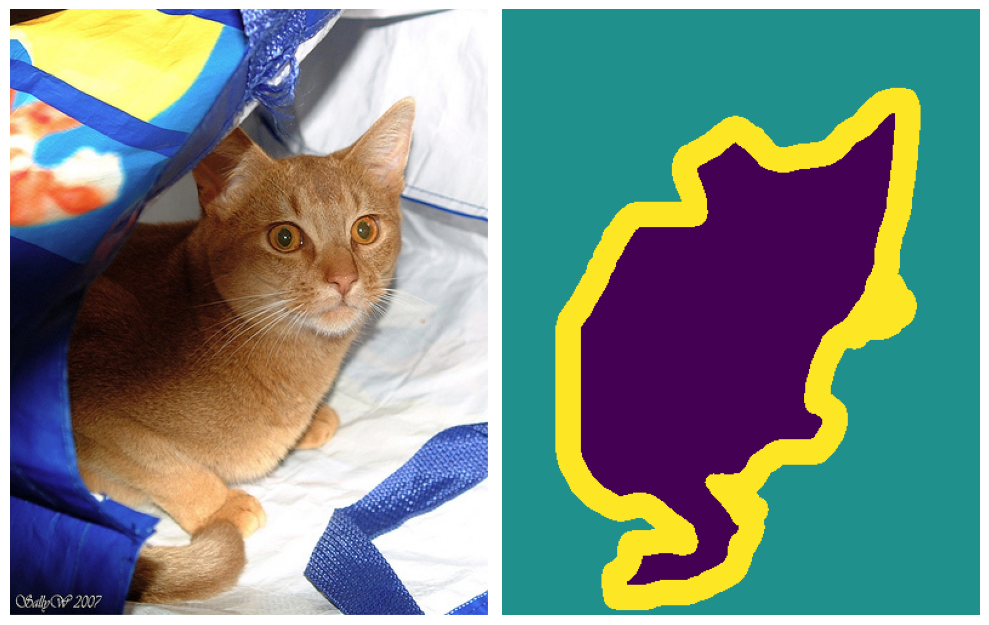

In [ ]:
# Viewing the Dataset

plt.figure(figsize = (10, 10))

plt.subplot(1, 2, 1)
plt.imshow(img.permute(1, 2, 0))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask)
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Creating Batches

Batch_size = 8

train_loader = DataLoader(train_data, batch_size = Batch_size, shuffle = True)
test_loader = DataLoader(test_data, batch_size = Batch_size, shuffle = True)

In [ ]:
# Data Tranformation

def data_transform(img, mask):

    # Resize image
    img = transforms.Resize((464, 500))(img)

    # Convert image to Tensor
    img = transforms.ToTensor()(img)

    # Resize mask using nearest-neighbor
    mask = transforms.Resize(
        (464, 500),
        interpolation=transforms.InterpolationMode.NEAREST
    )(mask)

    # Convert mask to Tensor
    mask = torch.from_numpy(
        np.array(mask, dtype=np.int64)
    )

    return img, mask


# Applying transformation
train_data.transforms = data_transform
test_data.transforms = data_transform

## 🔧 Why We Resize Images and Masks

Oxford-IIIT Pet images come in **different sizes**:

```
Image 1 → [3, 225, 300]
Image 2 → [3, 333, 500]
Image 3 → [3, 464, 500]
```

But a batch must be a single rectangular tensor `[B, 3, H, W]`. PyTorch's `DataLoader` tries to `torch.stack(batch)`, which **fails** when samples have different `H × W`. So every image and mask must be resized to the **same fixed size** before batching.

### Different interpolation for image vs. mask

- **Image → bilinear interpolation.** RGB pixel values are continuous, so smoothly blending neighboring pixels during resize is fine (and looks better).
- **Mask → nearest-neighbor interpolation.** The mask contains **discrete class labels** (`1, 2, 3`). Bilinear interpolation would blend them into invalid in-between values like `1.4` or `2.3`, which makes no sense as a class label. Nearest-neighbor just copies the closest pixel's value, so the mask always stays exactly `1, 2, or 3`.

```
Image  → Bilinear   → smooth pixel blending (fine for RGB)
Mask   → Nearest    → preserves exact class labels (1, 2, 3)
```

### What the code does

```python
img = transforms.Resize((464, 500))(img)                     # bilinear by default
mask = transforms.Resize((464, 500), interpolation=NEAREST)(mask)  # preserves labels
mask = torch.from_numpy(np.array(mask, dtype=np.int64))       # keep as integer class indices
```

The mask is also cast to `int64` (not `float`) since it holds class indices, not pixel intensities — matching what `CrossEntropyLoss` expects.

In [ ]:
# U-Net Class

class unet(nn.Module):

  def __init__(self, in_channel):
    super().__init__()

    # 3x3 conv layers (for Encoder)
    self.e1_c1 = nn.Conv2d(in_channel, 64, 3)
    self.e1_c2 = nn.Conv2d(64, 64, 3)

    self.en2_c1 = nn.Conv2d(64, 128, 3)
    self.en2_c2 = nn.Conv2d(128, 128, 3)

    self.en3_c1 = nn.Conv2d(128, 256, 3)
    self.en3_c2 = nn.Conv2d(256, 256, 3)

    self.en4_c1 = nn.Conv2d(256, 512, 3)
    self.en4_c2 = nn.Conv2d(512, 512, 3)

    self.relu = nn.ReLU()

    self.pool = nn.MaxPool2d(kernel_size = 2, stride = 2)

    # 3x3 conv layer (for Bottleneck)
    self.b1 = nn.Conv2d(512, 1024, 3)
    self.b2 = nn.Conv2d(1024, 1024, 3)

    # 2x2 Upsample layer (for Decoder)
    self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
    self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
    self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
    self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)

    self.d1_c1 = nn.Conv2d(1024, 512, 3)
    self.d1_c2 = nn.Conv2d(512, 512, 3)

    self.d2_c1 = nn.Conv2d(512, 256, 3)
    self.d2_c2 = nn.Conv2d(256, 256, 3)

    self.d3_c1 = nn.Conv2d(256, 128, 3)
    self.d3_c2 = nn.Conv2d(128, 128, 3)

    self.d4_c1 = nn.Conv2d(128, 64, 3)
    self.d4_c2 = nn.Conv2d(64, 64, 3)

    self.out = nn.Conv2d(64, 3, 1)    # 1x1 Conv - placed at the last of the decoder





  # Encoder
  def encoder(self, input_tensor):
    skip =[]

    e1 = self.e1_c1(input_tensor)
    e1 = self.relu(e1)
    e1 = self.e1_c2(e1)
    e1 = self.relu(e1)
    skip.append(e1)
    e1 = self.pool(e1)

    e2 = self.en2_c1(e1)
    e2 = self.relu(e2)
    e2 = self.en2_c2(e2)
    e2 = self.relu(e2)
    skip.append(e2)
    e2 = self.pool(e2)

    e3 = self.en3_c1(e2)
    e3 = self.relu(e3)
    e3 = self.en3_c2(e3)
    e3 = self.relu(e3)
    skip.append(e3)
    e3 = self.pool(e3)

    e4 = self.en4_c1(e3)
    e4 = self.relu(e4)
    e4 = self.en4_c2(e4)
    e4 = self.relu(e4)
    skip.append(e4)
    e4 = self.pool(e4)

    return e4, skip



  # Bottleneck
  def bottleneck(self, input_tensor):
    bottlneck = self.b1(input_tensor)
    bottlneck = self.relu(bottlneck)
    bottlneck = self.b2(bottlneck)
    bottlneck = self.relu(bottlneck)
    return bottlneck

  # Concatenating Upsampled and Skip tensors
  def concatenate(self, up_sample_tensor, skip_tensor):
    # skip tensor:       [B, C, H_skip, W_skip]
    # upsampled tensor:  [B, C, H_up,   W_up]

    diff_H = skip_tensor.shape[2] - up_sample_tensor.shape[2]
    diff_W = skip_tensor.shape[3] - up_sample_tensor.shape[3]

    # Cropping skip_tensor by difference value: If diff_W = 8, then cutting off 4 pixels from the left side (indices 0–3) and 4 pixels from the right side (indices 36–39),
    # this gives a perfectly centered pixel width cropping. And same way for Top-bottom or Height of the skip_tensor.
    skip_tensor = skip_tensor[
        : ,
        : ,
        diff_H // 2 : (diff_H // 2 + up_sample_tensor.shape[2]),
        diff_W // 2 : (diff_W // 2 + up_sample_tensor.shape[3])
    ]

    # Concatenating Upsampled and Cropped skip tensor
    final_tensor = torch.cat((up_sample_tensor, skip_tensor), dim = 1)   # PyTorch tracks tensor shapes uses a 4D layout convention:[Batch size, Channels, Height, Width],
    # which corresponds to indices [0, 1, 2, 3]. Setting dim=1 tells PyTorch to concatenate the arrays along the Channels axis.

    return final_tensor


  # Decoder
  def decoder(self, input_tensor, skip):

    d1 = self.up1(input_tensor)
    d1 = self.concatenate(d1, skip[3])
    d1 = self.d1_c1(d1)
    d1 = self.relu(d1)
    d1 = self.d1_c2(d1)
    d1 = self.relu(d1)

    d2 = self.up2(d1)
    d2 = self.concatenate(d2, skip[2])
    d2 = self.d2_c1(d2)
    d2 = self.relu(d2)
    d2 = self.d2_c2(d2)
    d2 = self.relu(d2)

    d3 = self.up3(d2)
    d3 = self.concatenate(d3, skip[1])
    d3 = self.d3_c1(d3)
    d3 = self.relu(d3)
    d3 = self.d3_c2(d3)
    d3 = self.relu(d3)

    d4 = self.up4(d3)
    d4 = self.concatenate(d4, skip[0])
    d4 = self.d4_c1(d4)
    d4 = self.relu(d4)
    d4 = self.d4_c2(d4)
    d4 = self.relu(d4)

    res = self.out(d4)
    return res




  # Forward Pass
  def forward(self, input_tensor):
    encoder_output, skip = self.encoder(input_tensor)
    bottleneck_out = self.bottleneck(encoder_output)
    seg_img = self.decoder(bottleneck_out, skip)
    return seg_img

In [ ]:
# Cheking the U-Net model

check_model = unet(3)

x = torch.randn(1, 3, 464, 500)

y = check_model(x)

print("Input :", x.shape)
print("Output:", y.shape)

print(sum(p.numel() for p in check_model.parameters()))

Input : torch.Size([1, 3, 464, 500])
Output: torch.Size([1, 3, 276, 308])
31031875


In [ ]:
# Defining the Loss function, Optimizer, and initializinf the model

model = unet(3)
model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr = 1e-3)

In [ ]:
# Training

Epochs = 5

model.train()

for epoch in range(Epochs):
  total_epoch_loss = 0

  for image, mask in train_loader:

    image = image.to(device)
    mask = mask.to(device)

    optimizer.zero_grad()
    pred_mask = model.forward(image)

    # Cropping original mask
    pred_mask_H = pred_mask.shape[2]
    pred_mask_W = pred_mask.shape[3]

    diff_H = mask.shape[1] - pred_mask_H
    diff_W = mask.shape[2] - pred_mask_W

    mask = mask[
        :,
        diff_H // 2 : diff_H // 2 + pred_mask_H,
        diff_W // 2 : diff_W // 2 + pred_mask_W
    ]

    # Converting original mask's labels to pred_mask labels (1,2,3 → 0,1,2)
    mask = (mask - 1).long()

    # Loss computation
    loss = criterion(pred_mask, mask)

    # Backpropagation
    loss.backward()

    # Updatdiff_W
    optimizer.step()

    # Accumulate batch loss
    total_epoch_loss += loss.item()

  # Calculate average epoch loss
  epoch_avg_loss = total_epoch_loss / len(train_loader)

  print(f'Epoch [{epoch + 1}/{Epochs}]: Loss: {epoch_avg_loss:.4f}')

Epoch [1/5]: Loss: 0.9794
Epoch [2/5]: Loss: 1.0317
Epoch [3/5]: Loss: 0.9600
Epoch [4/5]: Loss: 0.9023
Epoch [5/5]: Loss: 0.8896


## 🎯 Why We Crop the Mask and Subtract 1 (mask = (mask - 1))?

**1. Cropping the mask** — This U-Net uses `3×3` convolutions with **no padding** (valid convolutions), which shrink the spatial size at every layer. So the model's output (e.g. `276×308`) ends up smaller than the input/mask (`464×500`). Since `CrossEntropyLoss` needs the prediction and target to have the **same H × W**, we **center-crop the ground-truth mask** to match the prediction's size. We crop the mask, not the prediction, since the model's output size is fixed by the architecture.

**2. `mask - 1`** — Our dataset labels pixels as `1 (Pet), 2 (Background), 3 (Boundary)`. But `CrossEntropyLoss` expects class indices starting from `0`, matching the model's 3 output channels (`0, 1, 2`). So we shift the labels down by 1:

```
1 → 0 (Pet)
2 → 1 (Background)
3 → 2 (Boundary)
```

Each target value is just an **index** telling the loss which output channel is correct for that pixel — not a pixel intensity.

> ⚠️ We never modify `pred_mask` — only the ground-truth `mask` is cropped and reindexed to align with the model's output.

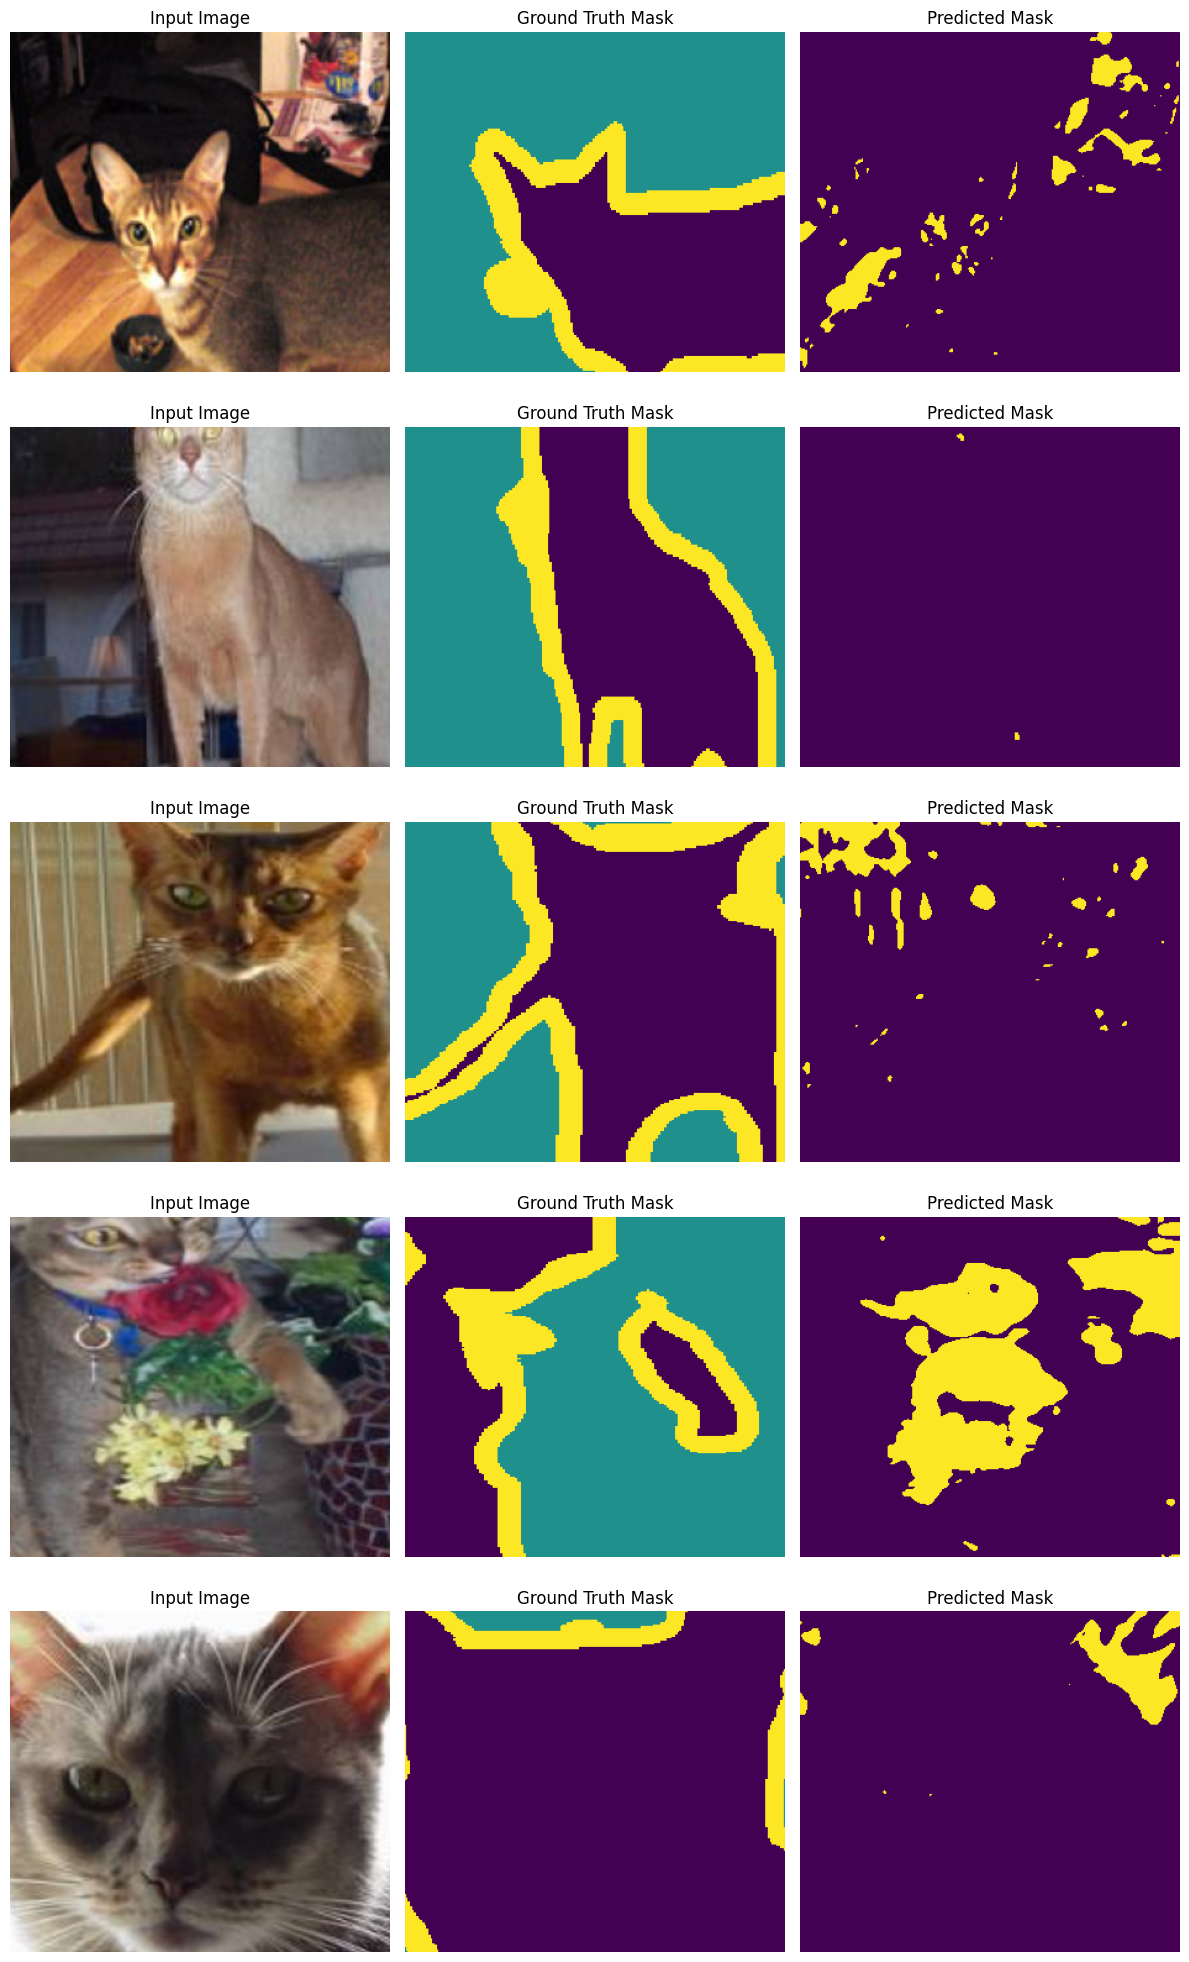

In [ ]:
# Visualizing how model segments

def visualize_predictions(model, dataset, device, num_samples=5):
    model.eval()

    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

    with torch.no_grad():
        for i in range(num_samples):
            image, mask = dataset[i]  # single sample, shape: image [3,H,W], mask [H,W]

            # Add batch dimension and move to device
            input_image = image.unsqueeze(0).to(device)

            pred_mask = model(input_image)  # [1, 3, H', W']

            # Crop ground-truth mask to match prediction size (same logic as training)
            pred_H, pred_W = pred_mask.shape[2], pred_mask.shape[3]
            diff_H = mask.shape[0] - pred_H
            diff_W = mask.shape[1] - pred_W

            cropped_mask = mask[
                diff_H // 2 : diff_H // 2 + pred_H,
                diff_W // 2 : diff_W // 2 + pred_W
            ]
            cropped_mask = (cropped_mask - 1).long()  # same label shift as training

            # Convert prediction logits -> class labels
            pred_labels = torch.argmax(pred_mask, dim=1).squeeze(0).cpu()  # [H', W']

            # Also crop the original image to match, just for clean side-by-side display
            img_H, img_W = image.shape[1], image.shape[2]
            diff_H_img = img_H - pred_H
            diff_W_img = img_W - pred_W
            cropped_image = image[
                :,
                diff_H_img // 2 : diff_H_img // 2 + pred_H,
                diff_W_img // 2 : diff_W_img // 2 + pred_W
            ]

            # Plot
            axes[i, 0].imshow(cropped_image.permute(1, 2, 0).numpy())
            axes[i, 0].set_title("Input Image")
            axes[i, 0].axis("off")

            axes[i, 1].imshow(cropped_mask.numpy(), cmap="viridis")
            axes[i, 1].set_title("Ground Truth Mask")
            axes[i, 1].axis("off")

            axes[i, 2].imshow(pred_labels.numpy(), cmap="viridis")
            axes[i, 2].set_title("Predicted Mask")
            axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

    model.train()  # switch back to training mode if you'll keep training after this


# Usage:
visualize_predictions(model, test_data, device, num_samples=5)